In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import os
import json
import glob
import torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses

/tmp/ipykernel_1735/2149139518.py:15: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses


In [2]:
def consolidar_jsons_sinteticos(caminho_diretorio: str) -> dict:
    dataset_consolidado = {}
    
    padrao_busca = os.path.join(caminho_diretorio, "*.json")
    arquivos_json = glob.glob(padrao_busca)
    
    if not arquivos_json:
        print(f"Falha de leitura: Nenhum arquivo .json encontrado no diretório '{caminho_diretorio}'.")
        return dataset_consolidado

    for caminho_arquivo in arquivos_json:
        nome_arquivo = os.path.basename(caminho_arquivo)
        
        try:
            with open(caminho_arquivo, "r", encoding="utf-8") as arquivo:
                conteudo = json.load(arquivo)
                
                # Valida se o conteúdo raiz do JSON é um objeto (dicionário)
                if isinstance(conteudo, dict):
                    dataset_consolidado.update(conteudo)
                else:
                    print(f"Falha estrutural: O arquivo '{nome_arquivo}' não possui um dicionário na raiz. Ignorado.")
                    
        except json.JSONDecodeError:
            print(f"Falha de parse: O arquivo '{nome_arquivo}' está corrompido ou não é um JSON válido.")
        except Exception as e:
            print(f"Falha de I/O no arquivo '{nome_arquivo}': {e}")
            
    return dataset_consolidado

In [3]:
def padronizar_lexico(dic_variaveis):
    textos_padronizados = []
    labels_categorias = []

    for macro_classe, lista_vars in dic_variaveis.items():
        for var in lista_vars:
            texto_limpo = var.lower()
            texto_limpo = re.sub(r'_', ' ', texto_limpo)
            textos_padronizados.append(texto_limpo)
            labels_categorias.append(macro_classe)

    return textos_padronizados, labels_categorias

In [4]:
def calibrar_modelo_dominio(textos, labels, nome_modelo_base, epochs=5, batch_size=16):
    print(f"\nIniciando Fine-Tuning de Alta Repulsão: {nome_modelo_base}")
    dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
    modelo = SentenceTransformer(nome_modelo_base, device=dispositivo)

    encoder = LabelEncoder()
    labels_int = encoder.fit_transform(labels)

    train_examples = []
    for texto, label in zip(textos, labels_int):
        train_examples.append(InputExample(texts=[texto], label=label))

    train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=batch_size)

    train_loss = losses.BatchHardTripletLoss(
        model=modelo,
        distance_metric=losses.BatchHardTripletLossDistanceFunction.cosine_distance,
        margin=0.6
    )

    modelo.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=epochs,
        warmup_steps=int(len(train_dataloader) * 0.1),
        show_progress_bar=True
    )

    return modelo

In [5]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def processar_e_plotar_modelos(dic_variaveis, lista_modelos):
    textos_limpos, labels = padronizar_lexico(dic_variaveis)
    n_modelos = len(lista_modelos)
    fig, axes = plt.subplots(1, n_modelos, figsize=(10 * n_modelos, 7))

    if n_modelos == 1:
        axes = [axes]

    modelo_final_calibrado = None

    for ax, nome_modelo in zip(axes, lista_modelos):
        modelo_calibrado = calibrar_modelo_dominio(textos_limpos, labels, nome_modelo)
        vetores = modelo_calibrado.encode(textos_limpos, show_progress_bar=False)

        try:
            sil_score = silhouette_score(vetores, labels)
            db_score = davies_bouldin_score(vetores, labels)
            ch_score = calinski_harabasz_score(vetores, labels)
            
            titulo_metricas = (
                f"{nome_modelo}\n"
                f"Silhouette: {sil_score:.3f} | Davies-Bouldin: {db_score:.3f}\n"
                f"Calinski-Harabasz: {ch_score:.1f}"
            )
        except ValueError:
            titulo_metricas = f"{nome_modelo}\nFalha no cálculo de métricas estruturais"

        redutor = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        vetores_2d = redutor.fit_transform(vetores)

        df_plot = pd.DataFrame({
            'Componente 1': vetores_2d[:, 0],
            'Componente 2': vetores_2d[:, 1],
            'Macro Classe': labels
        })

        sns.scatterplot(
            data=df_plot, x='Componente 1', y='Componente 2',
            hue='Macro Classe', palette='tab20', s=100, ax=ax, alpha=0.8
        )

        ax.set_title(titulo_metricas, pad=15)
        ax.legend(title='Macro Classes', bbox_to_anchor=(1.05, 1), loc='upper left')

        modelo_final_calibrado = modelo_calibrado

    plt.tight_layout()
    plt.show()

    return modelo_final_calibrado, textos_limpos, labels

In [6]:
def treinar_classificador_final(modelo_embeddings, textos_treino, labels_treino):
    print("\nExtraindo embeddings finais para a camada de decisão...")
    vetores_treino = modelo_embeddings.encode(textos_treino, show_progress_bar=False)

    encoder = LabelEncoder()
    y_treino = encoder.fit_transform(labels_treino)

    print("Treinando o classificador Regressão Logística...")
    classificador = LogisticRegression(max_iter=1000, random_state=42)
    classificador.fit(vetores_treino, y_treino)

    print("Pipeline de treinamento concluído.")
    return classificador, encoder

In [7]:
def predict_variavel(descricao_variavel, modelo_embeddings, classificador, encoder, limiar_confianca=0.50):
    vetor_entrada = modelo_embeddings.encode([descricao_variavel], show_progress_bar=False)
    probabilidades = classificador.predict_proba(vetor_entrada)[0]

    indice_vencedor = np.argmax(probabilidades)
    probabilidade_vencedora = probabilidades[indice_vencedor]

    if probabilidade_vencedora < limiar_confianca:
        return {
            "classe_predita": "UNCLASSIFIED",
            "confianca": float(probabilidade_vencedora),
            "alerta": f"Rejeitado pela trava de segurança (Limiar: {limiar_confianca})"
        }

    classe_final = encoder.inverse_transform([indice_vencedor])[0]

    return {
        "classe_predita": classe_final,
        "confianca": float(probabilidade_vencedora),
        "alerta": None
    }


Iniciando Fine-Tuning de Alta Repulsão: BAAI/bge-large-en-v1.5


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss


/home/andre/miniconda3/envs/sematic/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


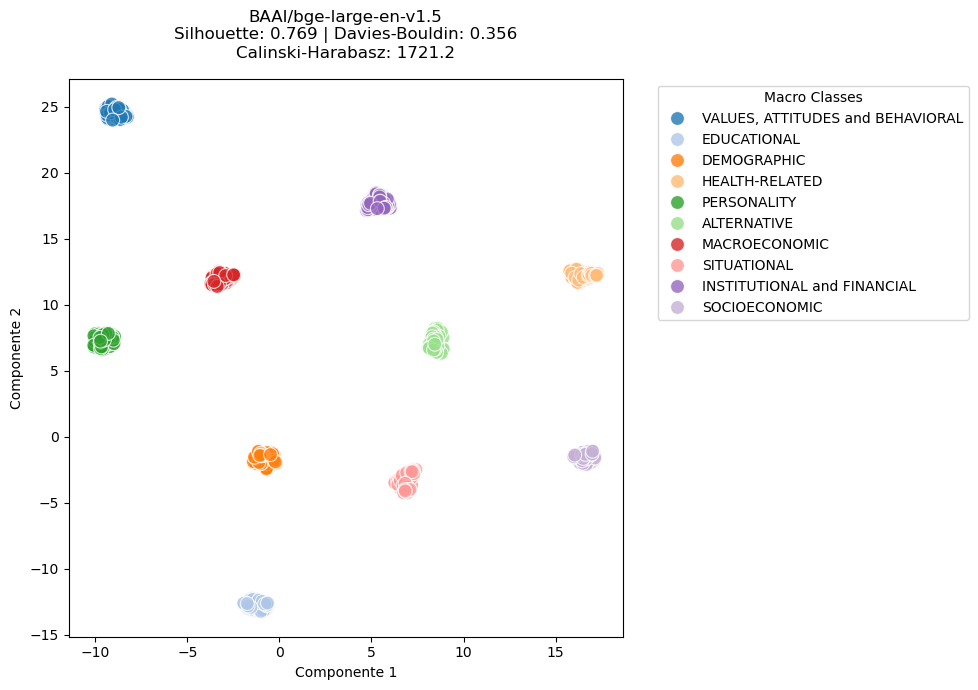

In [8]:
modelos_alvo = ['BAAI/bge-large-en-v1.5']
dados = consolidar_jsons_sinteticos("../data/output/SynteticData")
modelo_ajustado, textos_base, labels_base = processar_e_plotar_modelos(dados, modelos_alvo)

In [9]:
modelo_preditivo, label_encoder = treinar_classificador_final(modelo_ajustado, textos_base, labels_base)


Extraindo embeddings finais para a camada de decisão...
Treinando o classificador Regressão Logística...
Pipeline de treinamento concluído.


In [23]:
input_teste_1 = "Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool."
resultado_1 = predict_variavel(input_teste_1, modelo_ajustado, modelo_preditivo, label_encoder)

print(f"\n[TESTE 1] Input: '{input_teste_1}'")
print(f"Predição: {resultado_1['classe_predita']} (Acurácia de Decisão: {resultado_1['confianca']:.2f})")


[TESTE 1] Input: 'Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.'
Predição: EDUCATIONAL (Acurácia de Decisão: 0.86)


In [11]:
import pandas as pd
import json

caminho_prosper = "../data/input/PL.json"
def carregar_dados_prosper(caminho: str) -> pd.DataFrame:
    try:
        with open(caminho, 'r', encoding='utf-8') as f:
            dados_json = json.load(f)
        
        df_prosper = pd.DataFrame(dados_json)
        return df_prosper
        
    except FileNotFoundError:
        print(f"Falha de I/O: O arquivo '{caminho}' não foi encontrado.")
        return pd.DataFrame()
    except json.JSONDecodeError as e:
        print(f"Falha de parse estrutural: O arquivo JSON contém erros de formatação na sintaxe. {e}")
        return pd.DataFrame()
    except ValueError as e:
        print(f"Falha de conversão: Os dados carregados não formam uma estrutura tabular válida para o Pandas. {e}")
        return pd.DataFrame()

In [12]:
df_base = carregar_dados_prosper("../data/input/PL.json")
df_base

,var,desc
0,ListingKey,"Unique key for each listing, same value as the..."
1,ListingNumber,The number that uniquely identifies the listin...
2,ListingCreationDate,The date the listing was created.
3,CreditGrade,The Credit rating that was assigned at the tim...
4,Term,The length of the loan expressed in months.
...,...,...
76,PercentFunded,Percent the listing was funded.
77,Recommendations,Number of recommendations the borrower had at ...
78,InvestmentFromFriendsCount,Number of friends that made an investment in t...
79,InvestmentFromFriendsAmount,Dollar amount of investments that were made by...


In [13]:
df_macro = pd.read_csv("../data/input/MacroTaxonomyClassification.csv")
df_pl = df_macro[df_macro['id'] == 'd15']

In [14]:
df_pl

,id,Col,Col_Standardized
636,d15,ListingKey,UNCLASSIFIED
637,d15,ListingNumber,UNCLASSIFIED
638,d15,ListingCreationDate,UNCLASSIFIED
639,d15,CreditGrade,INSTITUTIONAL and FINANCIAL
640,d15,Term,INSTITUTIONAL and FINANCIAL
...,...,...,...
712,d15,PercentFunded,INSTITUTIONAL and FINANCIAL
713,d15,Recommendations,ALTERNATIVE
714,d15,InvestmentFromFriendsCount,ALTERNATIVE
715,d15,InvestmentFromFriendsAmount,ALTERNATIVE


In [ ]:
import pandas as pd

df_consolidado = pd.merge(
    df_base, 
    df_pl, 
    left_on='var', 
    right_on='Col', 
    how='inner' 
)

df_consolidado = df_consolidado.rename(columns={'Col_Standardized': 'macro_class'})

df_consolidado = df_consolidado[['id', 'var', 'desc', 'macro_class']]

df_consolidado = df_consolidado.reset_index(drop=True)

df_consolidado.head()

,id,var,desc,macro_class
0,d15,ListingKey,"Unique key for each listing, same value as the...",UNCLASSIFIED
1,d15,ListingNumber,The number that uniquely identifies the listin...,UNCLASSIFIED
2,d15,ListingCreationDate,The date the listing was created.,UNCLASSIFIED
3,d15,CreditGrade,The Credit rating that was assigned at the tim...,INSTITUTIONAL and FINANCIAL
4,d15,Term,The length of the loan expressed in months.,INSTITUTIONAL and FINANCIAL


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

resultados = df_consolidado['desc'].apply(
    lambda texto: predict_variavel(
        descricao_variavel=texto,
        modelo_embeddings=modelo_ajustado,
        classificador=modelo_preditivo,
        encoder=label_encoder, 
        limiar_confianca=0.50
    )
)

df_consolidado['classe_predita'] = resultados.apply(lambda x: x['classe_predita'])
df_consolidado['confianca_preditiva'] = resultados.apply(lambda x: x['confianca'])
df_consolidado['alerta_governanca'] = resultados.apply(lambda x: x['alerta'])

y_real = df_consolidado['macro_class']
y_pred = df_consolidado['classe_predita']

acuracia = accuracy_score(y_real, y_pred)
relatorio = classification_report(y_real, y_pred, zero_division=0)

print(f"Acurácia Global (com limiar de 0.50): {acuracia:.4f}\n")
print("Relatório de Classificação (Incluindo UNCLASSIFIED):")
print(relatorio)

df_consolidado[['var', 'macro_class', 'classe_predita', 'confianca_preditiva']].head()

Acurácia Global (com limiar de 0.50): 0.7342

Relatório de Classificação (Incluindo UNCLASSIFIED):
                             precision    recall  f1-score   support

                ALTERNATIVE       0.00      0.00      0.00         5
                DEMOGRAPHIC       0.00      0.00      0.00         0
INSTITUTIONAL and FINANCIAL       0.79      0.95      0.86        59
                SITUATIONAL       0.00      0.00      0.00         0
              SOCIOECONOMIC       0.67      0.25      0.36         8
               UNCLASSIFIED       0.00      0.00      0.00         7

                   accuracy                           0.73        79
                  macro avg       0.24      0.20      0.20        79
               weighted avg       0.66      0.73      0.68        79



,var,macro_class,classe_predita,confianca_preditiva
0,ListingKey,UNCLASSIFIED,ALTERNATIVE,0.870882
1,ListingNumber,UNCLASSIFIED,ALTERNATIVE,0.517190
2,ListingCreationDate,UNCLASSIFIED,INSTITUTIONAL and FINANCIAL,0.583022
3,CreditGrade,INSTITUTIONAL and FINANCIAL,INSTITUTIONAL and FINANCIAL,0.948050
4,Term,INSTITUTIONAL and FINANCIAL,INSTITUTIONAL and FINANCIAL,0.953389
